<a href="https://colab.research.google.com/github/aditiital/Digital-image-processing-Lab/blob/main/practical5_DIP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving rabbit_X-ray.jpg to rabbit_X-ray.jpg


/usr/local/lib/python3.12/dist-packages/scipy/signal/_signaltools.py:1783: RuntimeWarning: divide by zero encountered in divide
  res *= (1 - noise / lVar)
/usr/local/lib/python3.12/dist-packages/scipy/signal/_signaltools.py:1783: RuntimeWarning: invalid value encountered in multiply
  res *= (1 - noise / lVar)
/tmp/ipykernel_361/1473178703.py:44: RuntimeWarning: invalid value encountered in cast
  wiener_restored = np.uint8(np.clip(wiener_restored, 0, 255))


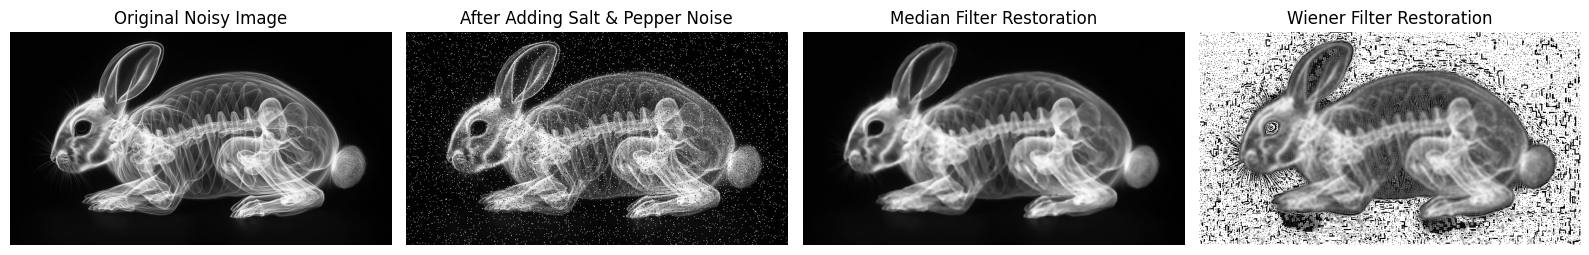

In [1]:

# Image Restoration using Median Filter and Wiener Filter

from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import wiener

# Upload a noisy X-ray image
uploaded = files.upload()

# Read input noisy image in grayscale
img = cv2.imread(next(iter(uploaded)), cv2.IMREAD_GRAYSCALE)

# -------------------------------
# Add More Salt-and-Pepper Noise
# -------------------------------
noisy_img = img.copy()

# Amount of additional noise
noise_density = 0.05

num_salt = int(noise_density * img.size / 2)
num_pepper = int(noise_density * img.size / 2)

# Add Salt Noise (White Pixels)
coords = [np.random.randint(0, i, num_salt) for i in img.shape]
noisy_img[coords[0], coords[1]] = 255

# Add Pepper Noise (Black Pixels)
coords = [np.random.randint(0, i, num_pepper) for i in img.shape]
noisy_img[coords[0], coords[1]] = 0

# -------------------------------
# Restoration Technique 1
# Median Filtering
# -------------------------------
median_restored = cv2.medianBlur(noisy_img, 5)
# -------------------------------
# Restoration Technique 2
# Wiener Filtering
# -------------------------------
wiener_restored = wiener(noisy_img, (5,5))
wiener_restored = np.uint8(np.clip(wiener_restored, 0, 255))

# -------------------------------
# Display Results
# -------------------------------
plt.figure(figsize=(16,5))

plt.subplot(1,4,1)
plt.imshow(img, cmap='gray')
plt.title("Original Noisy Image")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(noisy_img, cmap='gray')
plt.title("After Adding Salt & Pepper Noise")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(median_restored, cmap='gray')
plt.title("Median Filter Restoration")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(wiener_restored, cmap='gray')
plt.title("Wiener Filter Restoration")
plt.axis("off")

plt.tight_layout()
plt.show()

